# 🛡️ Machine Learning × Network Security

Notebook **เล่มที่ 3** — นำ ML ไปใช้กับงาน **network / security** จริง โดยเริ่มจากรากฐานที่ยังไม่ได้แตะในสองเล่มก่อน:
**classical ML** (decision tree, random forest) และ **unsupervised learning** (anomaly detection) แล้วต่อยอดขึ้นไปเรื่อย ๆ

| Part | เนื้อหา | แนวคิด ML | ใช้ในงานจริง |
|---|---|---|---|
| 1 | Network flow ในสายตา ML | feature engineering | ทุกระบบวิเคราะห์ traffic |
| 2 | จำแนกประเภท traffic | **classical ML** — Decision Tree, Random Forest | QoS, traffic shaping, app identification |
| 3 | ตรวจจับการบุกรุก (IDS) | **unsupervised** — Isolation Forest, Autoencoder | NIDS, ตรวจ zero-day |
| 4 | ตรวจจับโดเมน DGA | deep learning (char-level) | DNS security, ตรวจ botnet C2 |
| 5 | โจมตีโมเดลของเราเอง | **adversarial ML** — FGSM | evasion / robustness |
| 6 | จากแล็บสู่ของจริง | — | dataset & ระบบจริง |

> **ทำไม ML สำคัญกับ network security:** วิธีเดิม (signature / rule-based) จับได้แค่สิ่งที่ "เคยเห็นและเขียนกฎไว้แล้ว"
> แต่ traffic จริงมีปริมาณมหาศาล เข้ารหัสจนดู payload ไม่ได้ และการโจมตีแบบใหม่ไม่มีกฎรองรับ
> ML ช่วยเรียนรู้ "รูปแบบ" และ "ความผิดปกติ" จาก**สถิติของ flow** แทน — นี่คือหัวใจของ Part 1–3
>
> ⚠️ ข้อมูลทั้งหมดในเล่มนี้**สังเคราะห์ขึ้นเอง**เพื่อการเรียนรู้ — สะอาดกว่าของจริงมาก
> Part 6 จะชี้ dataset จริงและข้อจำกัดที่ต้องเจอเมื่อนำไปใช้งานจริง

In [1]:
# ── Setup ──
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Tahoma"            # ฟอนต์อักษรไทยสำหรับ plot
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

---
## Part 1 — Network Flow ในสายตา Machine Learning

ML ไม่ได้มองทีละ packet แต่มองเป็น **flow** = การสื่อสาร 1 ครั้งระหว่าง 2 เครื่อง (นิยามด้วย src/dst IP, port, protocol)
แล้วสรุปแต่ละ flow เป็น **ตัวเลขไม่กี่ค่า (features)** — นี่คือ *feature engineering* ขั้นแรกของงานสายนี้

| feature | ความหมาย | บอกอะไร |
|---|---|---|
| `duration_s` | flow นี้กินเวลานานเท่าไร | streaming ยาว, web สั้น |
| `total_bytes` | ส่งข้อมูลรวมกี่ไบต์ | bulk transfer ใหญ่, VoIP เล็ก |
| `n_packets` | จำนวน packet | — |
| `mean_pkt_size` | ขนาด packet เฉลี่ย | VoIP เล็ก (เสียง), bulk ใหญ่ (เต็ม MTU) |
| `bytes_per_s` | throughput | video สูงและสม่ำเสมอ |
| `pkts_per_s` | อัตรา packet | — |
| `dst_port` | port ปลายทาง | เคยบอก app ได้ แต่ยุคเข้ารหัสบอกไม่ได้แล้ว |

เราจะสังเคราะห์ flow ของ traffic 4 ประเภทที่มี "บุคลิก" ต่างกัน:
**web** (ขอแล้วจบเร็ว) · **video** (สตรีมยาว throughput สูง) · **voip** (packet เล็กถี่สม่ำเสมอ) · **bulk** (โอนไฟล์ใหญ่ packet เต็ม MTU)

In [2]:
# ── สังเคราะห์ network flow 4 ประเภท ──
# จงใจให้ web/video/bulk แชร์ port 443 (HTTPS) เป็นหลัก -> port แยกประเภทไม่ได้
# โมเดลจึง "ถูกบังคับ" ให้เรียนรู้จากรูปร่างของ flow แทน (เหมือน traffic เข้ารหัสจริง)

def make_flows(n_per_class, rng):
    rows, labels = [], []
    specs = {
        # ชนิด: duration(log μ,σ), total_bytes(log μ,σ), packet_size(μ,σ), ports ที่พบ
        "web":   dict(dur=(0.3, 1.0), by=(11.0, 1.6), psz=(700, 300),  ports=[443, 443, 443, 80]),
        "video": dict(dur=(4.0, 0.7), by=(15.2, 1.0), psz=(1200, 180), ports=[443, 443, 443, 8443]),
        "voip":  dict(dur=(3.2, 0.7), by=(9.2, 0.7),  psz=(170, 55),   ports=[443, 5060, 3478]),
        "bulk":  dict(dur=(2.3, 1.0), by=(15.7, 1.2), psz=(1430, 90),  ports=[443, 443, 22, 445]),
    }
    for cls, s in specs.items():
        dur = np.exp(rng.normal(*s["dur"], n_per_class)).clip(0.01, 7200)     # lognormal: ค่าบวก หางยาว
        total_bytes = np.exp(rng.normal(*s["by"], n_per_class)).clip(64, 5e9)
        pkt_size = rng.normal(*s["psz"], n_per_class).clip(40, 1500)          # 40=หัว TCP, 1500=MTU
        n_pkts = (total_bytes / pkt_size).clip(1, None)
        port = rng.choice(s["ports"], n_per_class)
        for i in range(n_per_class):
            rows.append([dur[i], total_bytes[i], n_pkts[i], pkt_size[i],
                         total_bytes[i] / dur[i], n_pkts[i] / dur[i], port[i]])
            labels.append(cls)
    return np.array(rows), np.array(labels)

FEATURES = ["duration_s", "total_bytes", "n_packets", "mean_pkt_size",
            "bytes_per_s", "pkts_per_s", "dst_port"]

rng = np.random.default_rng(42)
X, y = make_flows(500, rng)
print(f"สร้าง flow ทั้งหมด {len(X)} รายการ จาก {len(set(y))} ประเภท: {sorted(set(y))}")

# ดูตัวอย่างแต่ละประเภท (ค่าใหญ่ ๆ จัดเป็นหน่วยอ่านง่าย)
df = pd.DataFrame(X, columns=FEATURES); df["label"] = y
show = df.groupby("label").first().copy()
show["total_bytes"] = (show["total_bytes"] / 1e6).round(2).astype(str) + " MB"
show["bytes_per_s"] = (show["bytes_per_s"] / 1e3).round(1).astype(str) + " KB/s"
show[["duration_s", "n_packets", "mean_pkt_size", "dst_port"]] = \
    show[["duration_s", "n_packets", "mean_pkt_size", "dst_port"]].round(0).astype(int)
show.drop(columns="pkts_per_s")

สร้าง flow ทั้งหมด 2000 รายการ จาก 4 ประเภท: [np.str_('bulk'), np.str_('video'), np.str_('voip'), np.str_('web')]


,duration_s,total_bytes,n_packets,mean_pkt_size,bytes_per_s,dst_port
label,,,,,,
bulk,5,0.78 MB,581,1337,162.5 KB/s,445
video,68,1.9 MB,1700,1115,27.9 KB/s,443
voip,20,0.01 MB,62,130,0.4 KB/s,5060
web,2,0.53 MB,778,682,289.9 KB/s,443


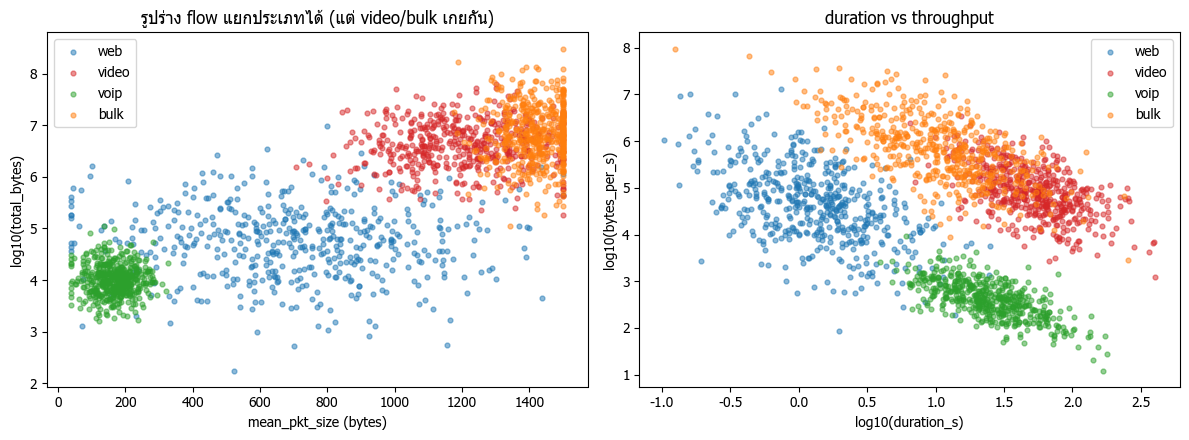

In [3]:
# ── มองข้อมูลเป็นภาพ: แต่ละประเภทอยู่คนละโซน แต่ทับซ้อนกันบ้าง ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"web": "tab:blue", "video": "tab:red", "voip": "tab:green", "bulk": "tab:orange"}

# (ซ้าย) ขนาด packet เฉลี่ย vs total bytes (log) — แยกกลุ่มได้ดีแต่ไม่ขาด
for cls in colors:
    m = y == cls
    axes[0].scatter(df["mean_pkt_size"][m], np.log10(df["total_bytes"][m]),
                    s=12, alpha=0.5, c=colors[cls], label=cls)
axes[0].set_xlabel("mean_pkt_size (bytes)"); axes[0].set_ylabel("log10(total_bytes)")
axes[0].set_title("รูปร่าง flow แยกประเภทได้ (แต่ video/bulk เกยกัน)")
axes[0].legend()

# (ขวา) duration vs throughput (log) — เห็นบุคลิกต่างชัด
for cls in colors:
    m = y == cls
    axes[1].scatter(np.log10(df["duration_s"][m]), np.log10(df["bytes_per_s"][m]),
                    s=12, alpha=0.5, c=colors[cls], label=cls)
axes[1].set_xlabel("log10(duration_s)"); axes[1].set_ylabel("log10(bytes_per_s)")
axes[1].set_title("duration vs throughput")
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Part 2 — จำแนกประเภท Traffic ด้วย Classical ML

นี่คือโจทย์ **supervised classification** บน **ข้อมูลตาราง (tabular)** — และพระเอกของงานแบบนี้
**ไม่ใช่** neural network แต่เป็นโมเดลตระกูล **ต้นไม้ตัดสินใจ (decision tree)**

**Decision Tree** = ชุดคำถาม if-else ที่เรียนรู้เอง เช่น *"mean_pkt_size < 250 ไหม? ถ้าใช่ → VoIP"*
อ่านเข้าใจง่ายว่ามันตัดสินใจยังไง (interpretable) แต่ต้นเดียวมัก overfit

**Random Forest** = ปลูกต้นไม้หลายร้อยต้น แต่ละต้นเห็นข้อมูล/feature คนละมุม แล้ว**โหวตกัน**
→ แม่นกว่าและทนต่อ noise มากกว่าต้นเดียว (เป็น *ensemble* — รวมพลังโมเดลอ่อน ๆ หลายตัว)

> ทำไมไม่ใช้ neural network? บนข้อมูลตารางที่ feature มีความหมายชัด ต้นไม้มัก**ชนะ** NN ทั้งความแม่น
> ความเร็ว และการอธิบายได้ — เป็นบทเรียนสำคัญ: **เลือกเครื่องมือให้เหมาะกับชนิดข้อมูล**

In [4]:
# ── แบ่งข้อมูล train/test แล้วเทียบ Decision Tree กับ Random Forest ──
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# stratify=y -> ให้สัดส่วนแต่ละ class ใน train/test เท่ากัน
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

results = {}
for name, clf in [
    ("Decision Tree (ลึก 4)", DecisionTreeClassifier(max_depth=4, random_state=0)),
    ("Decision Tree (ลึก 8)", DecisionTreeClassifier(max_depth=8, random_state=0)),
    ("Random Forest (120 ต้น)", RandomForestClassifier(n_estimators=120, random_state=0)),
]:
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    results[name] = acc
    print(f"{name:26} accuracy = {acc:.3f}")

print("\n→ ต้นไม้ลึกขึ้น = แม่นขึ้น (แต่เสี่ยง overfit) | Random Forest แม่นสุดและเสถียรสุด")

Decision Tree (ลึก 4)      accuracy = 0.895
Decision Tree (ลึก 8)      accuracy = 0.935
Random Forest (120 ต้น)    accuracy = 0.953

→ ต้นไม้ลึกขึ้น = แม่นขึ้น (แต่เสี่ยง overfit) | Random Forest แม่นสุดและเสถียรสุด


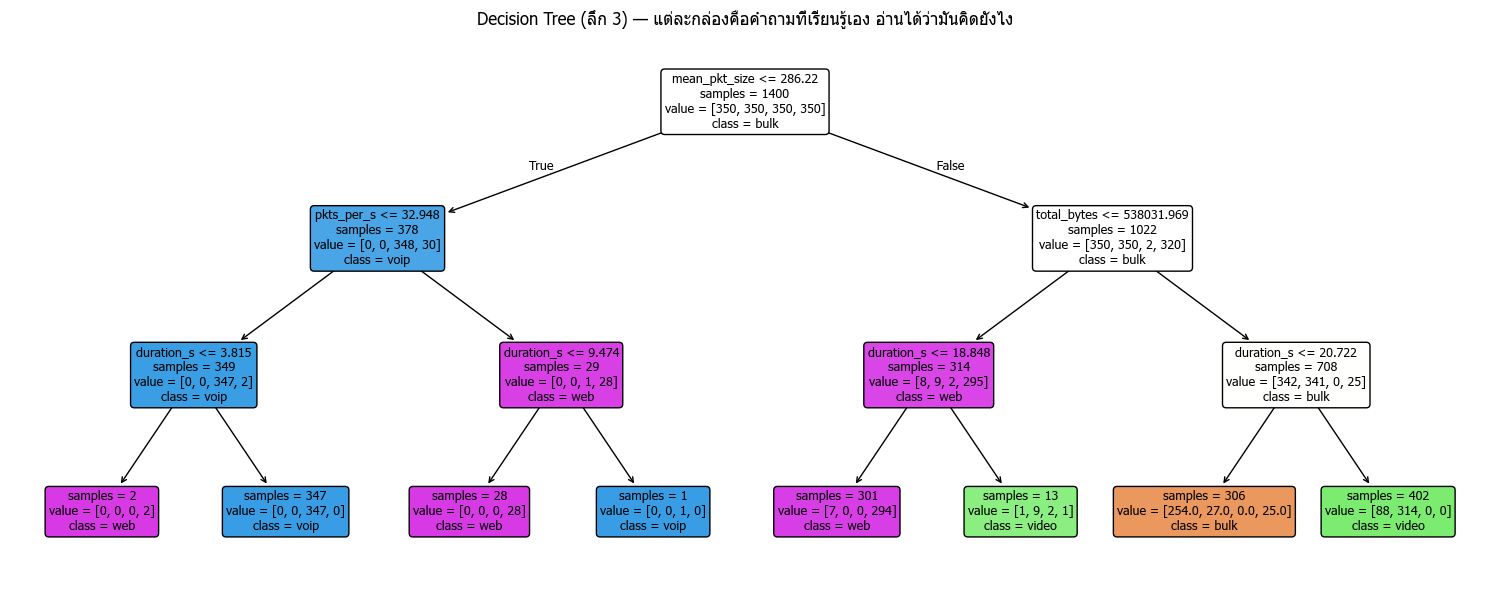

In [5]:
# ── เปิดดู "สมอง" ของ Decision Tree (ตื้น ๆ เพื่ออ่านได้) ──
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tr, y_tr)
plt.figure(figsize=(15, 6))
plot_tree(tree, feature_names=FEATURES, class_names=sorted(set(y)),
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("Decision Tree (ลึก 3) — แต่ละกล่องคือคำถามที่เรียนรู้เอง อ่านได้ว่ามันคิดยังไง")
plt.tight_layout(); plt.show()
# อ่านจากบนลงล่าง: โมเดลถามทีละ feature เพื่อค่อย ๆ แยก 4 ประเภทออกจากกัน

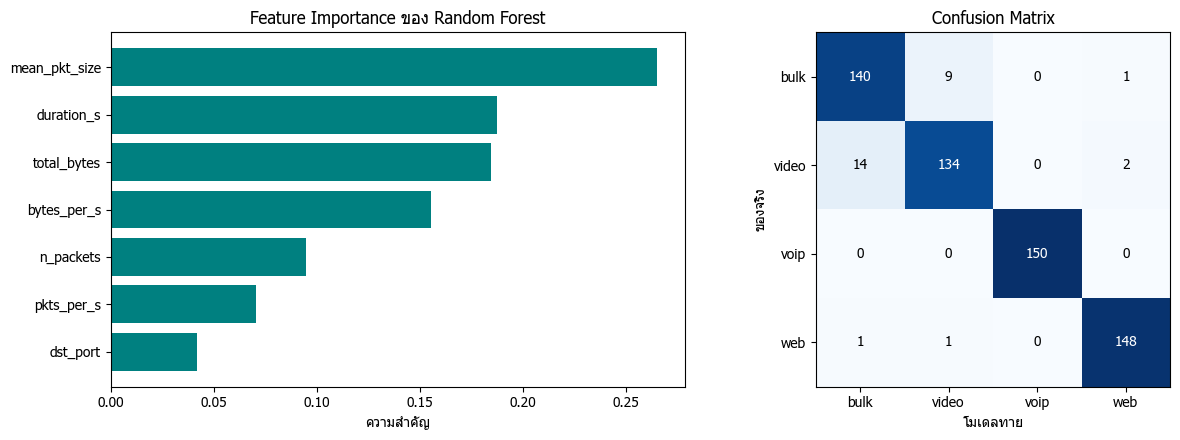

💡 dst_port สำคัญแค่ ~4% — โมเดล 'แทบไม่ใช้ port' เลย!
   มันเรียนรู้จากรูปร่าง flow (ขนาด packet, ระยะเวลา, ปริมาณ) แทน
   = หลักการเดียวกับการวิเคราะห์ traffic ที่เข้ารหัส (HTTPS/VPN) ในโลกจริง
   ส่วนที่สับสนคือ video ↔ bulk เพราะทั้งคู่เป็นการโอนข้อมูลก้อนใหญ่บน 443 เหมือนกัน


In [6]:
# ── feature ไหนสำคัญที่สุด? + โมเดลสับสนคู่ไหน? ──
rf = RandomForestClassifier(n_estimators=120, random_state=0).fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (ซ้าย) feature importance — ดูว่าโมเดลพึ่งพา feature ใดในการตัดสิน
imp = sorted(zip(FEATURES, rf.feature_importances_), key=lambda t: t[1])
axes[0].barh([n for n, _ in imp], [v for _, v in imp], color="teal")
axes[0].set_title("Feature Importance ของ Random Forest")
axes[0].set_xlabel("ความสำคัญ")

# (ขวา) confusion matrix
labels = sorted(set(y))
cm = confusion_matrix(y_te, rf.predict(X_te), labels=labels)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(4), labels); axes[1].set_yticks(range(4), labels)
axes[1].set_xlabel("โมเดลทาย"); axes[1].set_ylabel("ของจริง")
axes[1].set_title("Confusion Matrix")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

print(f"💡 dst_port สำคัญแค่ ~{dict(imp)['dst_port']:.0%} — โมเดล 'แทบไม่ใช้ port' เลย!")
print("   มันเรียนรู้จากรูปร่าง flow (ขนาด packet, ระยะเวลา, ปริมาณ) แทน")
print("   = หลักการเดียวกับการวิเคราะห์ traffic ที่เข้ารหัส (HTTPS/VPN) ในโลกจริง")
print("   ส่วนที่สับสนคือ video ↔ bulk เพราะทั้งคู่เป็นการโอนข้อมูลก้อนใหญ่บน 443 เหมือนกัน")

---
## Part 3 — ตรวจจับการบุกรุก (IDS) ด้วย Unsupervised Learning

Part 2 ต้องมี **label** ("flow นี้คือ web") แต่การโจมตีแบบใหม่ (zero-day) **ไม่มี label** ให้เรียน
และเราเขียน signature ล่วงหน้าไม่ได้เพราะยังไม่เคยเห็น

ทางออกคือพลิกมุมคิด: **เรียนรู้ว่า "ปกติ" หน้าตาเป็นยังไง แล้วจับทุกอย่างที่ผิดไปจากนั้น** (anomaly detection)
— เป็น **unsupervised learning**: train ด้วยข้อมูล traffic ปกติ*อย่างเดียว* ไม่ต้องมีตัวอย่างการโจมตี

| วิธีเดิม (Signature-based) | Anomaly-based (ML) |
|---|---|
| จับเฉพาะการโจมตีที่รู้จัก (มีกฎแล้ว) | จับสิ่งผิดปกติ แม้ไม่เคยเห็นมาก่อน |
| false positive ต่ำ | false positive สูงกว่า (ของแปลก ≠ อันตรายเสมอ) |
| เลี่ยงง่ายถ้าดัดแปลงนิดหน่อย | จับการดัดแปลงได้ดีกว่า |

เราจะลองตรวจจับการโจมตี 2 แบบที่ "รูปร่าง flow ผิดธรรมชาติ":
**Port scan** (ยิงสำรวจหลาย port — byte น้อย สั้นมาก) · **DDoS** (ถล่ม packet — อัตราสูงผิดปกติ)

In [7]:
# ── สังเคราะห์ flow การโจมตี (ใช้ตอน "ทดสอบ" เท่านั้น ไม่เอาไป train) ──
def make_attacks(n, rng):
    rows, kinds = [], []
    for _ in range(n):   # port scan: byte/packet น้อยมาก, สั้นมาก, ยิงสุ่ม port
        dur = np.exp(rng.normal(-3.0, 0.5)); tb = rng.uniform(40, 200); ps = rng.uniform(40, 80)
        npk = max(1, tb / ps)
        rows.append([dur, tb, npk, ps, tb / dur, npk / dur, rng.integers(1, 65535)])
        kinds.append("portscan")
    for _ in range(n):   # ddos: อัตรา packet สูงมาก, packet เล็ก
        dur = np.exp(rng.normal(1.5, 0.4)); ps = rng.uniform(40, 100); npk = np.exp(rng.normal(11, 0.5))
        tb = npk * ps
        rows.append([dur, tb, npk, ps, tb / dur, npk / dur, rng.choice([80, 443])])
        kinds.append("ddos")
    return np.array(rows), np.array(kinds)

X_attack, attack_kind = make_attacks(150, rng)

# feature หลายตัว skew หนัก (หางยาว) -> log ก่อน เพื่อให้โมเดลทำงานดีขึ้น
def log_transform(Xraw):
    Xt = Xraw.copy()
    for j in [0, 1, 2, 4, 5]:                 # duration, bytes, packets, bps, pps
        Xt[:, j] = np.log1p(Xt[:, j])
    return Xt

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(log_transform(X))           # ★ fit ด้วย "ปกติ" เท่านั้น
Xn = scaler.transform(log_transform(X))                   # normal (ไม่ใช้ label)
Xa = scaler.transform(log_transform(X_attack))            # attack (ไว้ทดสอบ)
print(f"train ด้วย normal {len(Xn)} flow (ไม่มี label) | ทดสอบด้วย attack {len(Xa)} flow")

train ด้วย normal 2000 flow (ไม่มี label) | ทดสอบด้วย attack 300 flow


False positive บน traffic ปกติ : 2.0%
ตรวจจับการโจมตีได้รวม           : 90.0%
   - portscan : 100.0%
   - ddos     : 80.0%


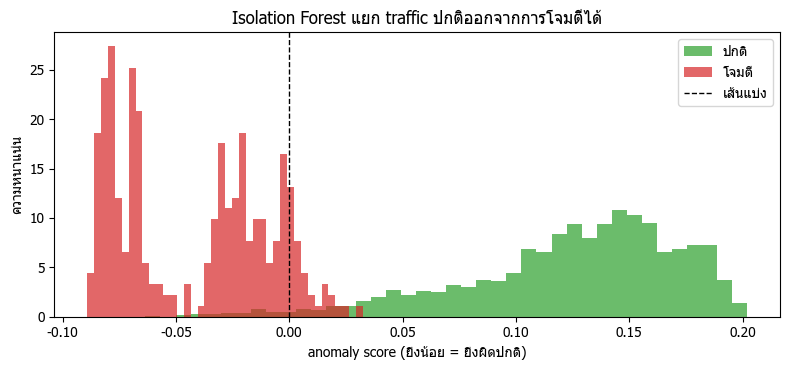

In [8]:
# ── วิธีที่ 1: Isolation Forest ──
# ไอเดีย: จุดที่ "ผิดปกติ" จะถูกสุ่มตัดแยกออกได้ง่าย (ใช้คำถามน้อยครั้ง) กว่าจุดปกติที่อยู่กระจุก
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=0).fit(Xn)   # คาดว่า ~2% ของ normal จะถูกมองเป็น outlier
pred_normal = iso.predict(Xn)      # -1 = ผิดปกติ, 1 = ปกติ
pred_attack = iso.predict(Xa)

false_alarm = np.mean(pred_normal == -1)
detect_rate = np.mean(pred_attack == -1)
print(f"False positive บน traffic ปกติ : {false_alarm:.1%}")
print(f"ตรวจจับการโจมตีได้รวม           : {detect_rate:.1%}")
for k in ["portscan", "ddos"]:
    m = attack_kind == k
    print(f"   - {k:9}: {np.mean(pred_attack[m] == -1):.1%}")

# ดูคะแนนความผิดปกติ: normal กับ attack แยกกันชัด
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(iso.decision_function(Xn), bins=40, alpha=0.7, label="ปกติ", color="tab:green", density=True)
ax.hist(iso.decision_function(Xa), bins=40, alpha=0.7, label="โจมตี", color="tab:red", density=True)
ax.axvline(0, color="k", ls="--", lw=1, label="เส้นแบ่ง")
ax.set_xlabel("anomaly score (ยิ่งน้อย = ยิ่งผิดปกติ)"); ax.set_ylabel("ความหนาแน่น")
ax.set_title("Isolation Forest แยก traffic ปกติออกจากการโจมตีได้"); ax.legend()
plt.tight_layout(); plt.show()

threshold (97th percentile ของ normal): 0.100
False positive : 3.0%
ตรวจจับโจมตี   : 100.0%


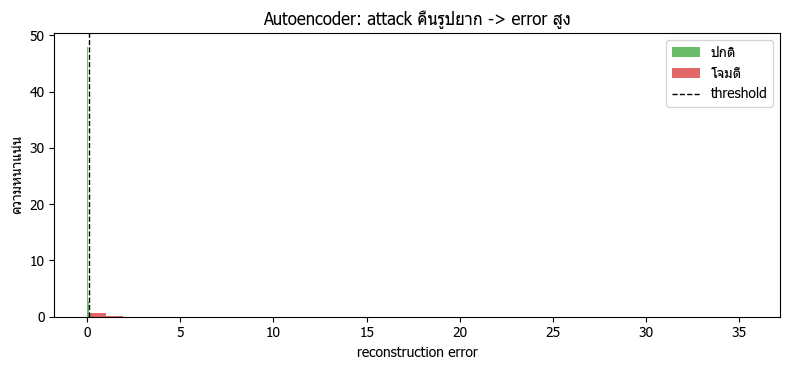

In [9]:
# ── วิธีที่ 2: Autoencoder (เชื่อมกับ deep learning จากเล่ม 1) ──
# ไอเดีย: train ให้ neural net "บีบแล้วคืนรูป" traffic ปกติได้แม่น
# พอเจอ attack ที่ไม่เหมือนข้อมูล train -> คืนรูปได้แย่ -> reconstruction error สูง = ผิดปกติ
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel("ERROR")
keras.utils.set_random_seed(0)

d = Xn.shape[1]
autoencoder = keras.Sequential([
    keras.Input((d,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(3,  activation="relu"),     # คอขวด: บีบเหลือ 3 มิติ บังคับให้เรียน "แก่น" ของ normal
    layers.Dense(16, activation="relu"),
    layers.Dense(d),                          # คืนรูปกลับเป็น d มิติเดิม
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(Xn, Xn, epochs=60, batch_size=64, verbose=0)   # target = input เอง

err_normal = np.mean((autoencoder.predict(Xn, verbose=0) - Xn) ** 2, axis=1)
err_attack = np.mean((autoencoder.predict(Xa, verbose=0) - Xa) ** 2, axis=1)
threshold = np.percentile(err_normal, 97)     # ตั้ง threshold จาก normal: ยอม false positive ~3%

print(f"threshold (97th percentile ของ normal): {threshold:.3f}")
print(f"False positive : {np.mean(err_normal > threshold):.1%}")
print(f"ตรวจจับโจมตี   : {np.mean(err_attack > threshold):.1%}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(err_normal, bins=40, alpha=0.7, label="ปกติ", color="tab:green", density=True)
ax.hist(np.clip(err_attack, None, np.percentile(err_attack, 99)), bins=40, alpha=0.7,
        label="โจมตี", color="tab:red", density=True)
ax.axvline(threshold, color="k", ls="--", lw=1, label="threshold")
ax.set_xlabel("reconstruction error"); ax.set_ylabel("ความหนาแน่น")
ax.set_title("Autoencoder: attack คืนรูปยาก -> error สูง"); ax.legend()
plt.tight_layout(); plt.show()

> **บทเรียนสำคัญของ anomaly detection — เรื่อง false positive:**
> ในแล็บข้อมูลสะอาด ทั้งสองวิธีจับการโจมตีได้สูง (port scan แทบ 100% เพราะรูปร่างผิดธรรมชาติชัด
> ส่วน DDoS ยากกว่าเล็กน้อยเพราะปริมาณมันกลมกลืนกับ traffic หนักปกติ)
> แต่ในโลกจริงที่ traffic วิ่งระดับ **ล้าน flow/วินาที** แม้ false positive แค่ 1% ก็หมายถึง
> สัญญาณเตือนปลอม**หมื่นครั้ง**ที่ทีม security ต้องไล่ดู — จนเกิด "alert fatigue"
>
> นี่คือเหตุผลที่ระบบจริงต้องชั่งน้ำหนัก **precision vs recall** อย่างระมัดระวัง (ตามที่เจอใน `ML_Fundamentals` Part 6)
> และมักใช้หลายวิธีร่วมกัน (signature + anomaly + threat intel) ไม่พึ่งอย่างใดอย่างหนึ่ง

---
## Part 4 — ตรวจจับโดเมน DGA ด้วย Deep Learning

มัลแวร์ (botnet) ต้องติดต่อ **C2 server** (command & control) เพื่อรับคำสั่ง
ถ้า hardcode โดเมนไว้ พอโดเมนถูกบล็อกก็ตายทั้งระบบ จึงใช้ **DGA (Domain Generation Algorithm)**:
อัลกอริทึมสร้างโดเมนสุ่ม**วันละหลายพันชื่อ** (เช่น `xufqle8z3p.com`) ทั้ง malware และ attacker รันสูตรเดียวกัน
เพื่อ "นัดเจอ" กันที่โดเมนของวันนั้น — ทำให้บล็อกล่วงหน้าแทบเป็นไปไม่ได้

วิธีจับ: โดเมน DGA **"หน้าตาสุ่ม"** ต่างจากโดเมนจริงที่คนตั้ง (มักออกเสียงได้)
เอาความรู้ char-level model จากเล่มก่อนมาใช้ — ให้โมเดลเรียนแยกเองจาก**ลำดับตัวอักษร**

In [10]:
# ── สังเคราะห์โดเมนจริง vs โดเมน DGA ──
syllables = ["ka","to","mi","re","sun","lo","na","be","ta","ro","li","mo","den","fast","green",
             "cloud","net","web","data","mail","shop","page","cat","dog","fox","tree","star","blue","red","sky"]
tlds = [".com", ".net", ".org", ".io"]

def legit_domain(rng):
    """โดเมนที่ 'คนตั้ง' — ต่อพยางค์ที่ออกเสียงได้"""
    return "".join(rng.choice(syllables, rng.integers(2, 4))) + rng.choice(tlds)

def dga_domain(rng):
    """โดเมน DGA — สุ่มตัวอักษร/ตัวเลขล้วน"""
    L = rng.integers(12, 22)
    return "".join(rng.choice(list("abcdefghijklmnopqrstuvwxyz0123456789"), L)) + rng.choice(tlds)

rng_d = np.random.default_rng(7)
domains = [legit_domain(rng_d) for _ in range(2000)] + [dga_domain(rng_d) for _ in range(2000)]
y_dga = np.array([0] * 2000 + [1] * 2000)    # 0 = จริง, 1 = DGA

print("ตัวอย่างโดเมนจริง :", [legit_domain(rng_d) for _ in range(4)])
print("ตัวอย่างโดเมน DGA :", [dga_domain(rng_d) for _ in range(4)])

ตัวอย่างโดเมนจริง : ['greenna.net', 'taroweb.org', 'denbe.com', 'lidenta.net']


ตัวอย่างโดเมน DGA : ['y9cc1388645vb5lvdyd.net', '6b870vxlqieay.com', 'xurvljqtnhzpt.net', 'ja5tp5sjfm71efpv.org']


In [11]:
# ── char-level CNN: เรียนรู้จากลำดับตัวอักษรของโดเมน ──
charset = sorted(set("".join(domains)))
char2id = {c: i + 1 for i, c in enumerate(charset)}   # 0 = ช่องว่าง (padding)
maxlen = max(len(d) for d in domains)

def encode_domain(s):
    v = [char2id.get(c, 0) for c in s][:maxlen]       # ตัวอักษรนอก charset (เช่น '-') -> 0
    return v + [0] * (maxlen - len(v))                # เติม 0 ให้ยาวเท่ากัน

X_dom = np.array([encode_domain(s) for s in domains])
X_dtr, X_dte, y_dtr, y_dte = train_test_split(X_dom, y_dga, test_size=0.25,
                                              random_state=0, stratify=y_dga)

keras.utils.set_random_seed(1)
dga_model = keras.Sequential([
    keras.Input((maxlen,)),
    layers.Embedding(len(charset) + 1, 16),           # ตัวอักษร -> เวกเตอร์ (เหมือน token embedding)
    layers.Conv1D(32, 3, activation="relu"),          # สแกนหา pattern ของตัวอักษร 3 ตัวติดกัน
    layers.GlobalMaxPooling1D(),                       # ดึง pattern ที่เด่นสุดของทั้งโดเมน
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),             # ความน่าจะเป็นที่จะเป็น DGA
])
dga_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
dga_model.fit(X_dtr, y_dtr, epochs=5, batch_size=128, verbose=0)
acc = dga_model.evaluate(X_dte, y_dte, verbose=0)[1]
print(f"ความแม่นยำในการแยกโดเมนจริง vs DGA: {acc:.1%}")

ความแม่นยำในการแยกโดเมนจริง vs DGA: 99.9%


In [12]:
# ── ด้านมืด: ตรวจ "ความสุ่ม" ไม่พอ — DGA ที่อ่านออกเสียงได้จะหลุดรอด ──
def dga_score(domain_list):
    arr = np.array([encode_domain(d) for d in domain_list])
    return dga_model.predict(arr, verbose=0).ravel()

# โดเมนมุ่งร้ายแต่จงใจตั้งให้ "อ่านออกเสียงได้" (เลียนแบบ dictionary-DGA ที่ใช้จริง)
evasive = ["securelogin-update.com", "cloud-backup-fast.net", "data-sync-page.io",
           "webshop-cat-store.com", "sunny-cloud-net.net", "green-mail-server.org"]
random_dga = [dga_domain(rng_d) for _ in range(6)]

print("คะแนน DGA (ใกล้ 1 = โมเดลว่าอันตราย, ใกล้ 0 = ว่าปลอดภัย)\n")
print("โดเมนมุ่งร้ายที่อ่านออกเสียงได้ (เลียน dictionary-DGA):")
for d, s in zip(evasive, dga_score(evasive)):
    print(f"   {s:.2f}  {d}")
print("\nโดเมน DGA สุ่มล้วน:")
for d, s in zip(random_dga, dga_score(random_dga)):
    print(f"   {s:.2f}  {d}")

print("\n💡 โมเดลจับ DGA สุ่มได้เกือบเป๊ะ แต่โดเมนมุ่งร้ายที่อ่านออกเสียงได้ส่วนใหญ่ 'หลุดรอด' (คะแนนต่ำ)")
print("   บทเรียน: ความสุ่มของตัวอักษร ≠ ความมุ่งร้าย — ระบบจริงต้องดูพฤติกรรม DNS,")
print("   อายุโดเมน, และ threat intel ประกอบ ไม่พึ่ง lexical อย่างเดียว (defense in depth)")

คะแนน DGA (ใกล้ 1 = โมเดลว่าอันตราย, ใกล้ 0 = ว่าปลอดภัย)

โดเมนมุ่งร้ายที่อ่านออกเสียงได้ (เลียน dictionary-DGA):
   0.01  securelogin-update.com
   0.01  cloud-backup-fast.net
   0.01  data-sync-page.io
   0.01  webshop-cat-store.com
   0.01  sunny-cloud-net.net
   0.66  green-mail-server.org

โดเมน DGA สุ่มล้วน:
   1.00  82c6q4jgw1wvrombsv.com
   1.00  5zkvgf2zzeeepyd6.io
   1.00  d71f5dzrxjujhgmk60g.net
   1.00  rjfrwdyvmitnjjc.com
   1.00  ya3688bfa3ju5.io
   1.00  vds5nunc5jkxf195kcd6.net

💡 โมเดลจับ DGA สุ่มได้เกือบเป๊ะ แต่โดเมนมุ่งร้ายที่อ่านออกเสียงได้ส่วนใหญ่ 'หลุดรอด' (คะแนนต่ำ)
   บทเรียน: ความสุ่มของตัวอักษร ≠ ความมุ่งร้าย — ระบบจริงต้องดูพฤติกรรม DNS,
   อายุโดเมน, และ threat intel ประกอบ ไม่พึ่ง lexical อย่างเดียว (defense in depth)


---
## Part 5 — โจมตีโมเดลของเราเอง: Adversarial Machine Learning

จนถึงตอนนี้ ML เป็น "ฝ่ายป้องกัน" แต่ในสาย security ตัวโมเดลเองก็**ถูกโจมตีได้**
**Adversarial example** = input ที่ถูกแต่งเติมด้วย noise จิ๋ว ๆ (ตามองแทบไม่เห็น) แต่ทำให้โมเดลทายผิดสนิท

วิธีคลาสสิกคือ **FGSM (Fast Gradient Sign Method)**: ปกติเราใช้ gradient ปรับ *weight* ให้ loss ลด
แต่คราวนี้ตรึง weight ไว้ แล้วใช้ gradient ปรับ *ภาพ input* ให้ loss **เพิ่ม** ในทิศที่ได้ผลที่สุด:

$$x_{adv} = x + \epsilon \cdot \text{sign}\!\left(\nabla_x\, L(\theta, x, y)\right)$$

- $\nabla_x L$ = ทิศที่ทำให้โมเดลผิดมากขึ้น (เทียบกับ *ภาพ* ไม่ใช่ weight)
- $\text{sign}$ = เอาแค่ทิศทาง (+/−) ของแต่ละ pixel
- $\epsilon$ = ความแรงของการรบกวน (เล็ก = มองไม่เห็น)

เอา CNN ตัวจำแนกเลข MNIST จาก `ML_Fundamentals` มาเป็นเป้า

In [13]:
# ── เตรียม CNN เป้าหมาย (เทรนเร็ว ๆ บน MNIST) ──
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

keras.utils.set_random_seed(42)
cnn = keras.Sequential([
    keras.Input((28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(), layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(x_train[..., None], y_train, epochs=2, batch_size=128, verbose=0)
clean_acc = cnn.evaluate(x_test[..., None], y_test, verbose=0)[1]
print(f"ความแม่นยำบนภาพปกติ: {clean_acc:.1%}")

def fgsm(model, images, labels, eps):
    """สร้าง adversarial examples แบบ batch ด้วย FGSM"""
    x = tf.convert_to_tensor(images[..., None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        loss = keras.losses.sparse_categorical_crossentropy(labels, model(x))
    grad = tape.gradient(loss, x)                          # ∇x L : ภาพควรเปลี่ยนทางไหนให้ loss เพิ่ม
    x_adv = tf.clip_by_value(x + eps * tf.sign(grad), 0, 1)  # เดินตามทิศ sign แล้วคุมให้อยู่ใน [0,1]
    return x_adv.numpy()[..., 0]

ความแม่นยำบนภาพปกติ: 98.2%


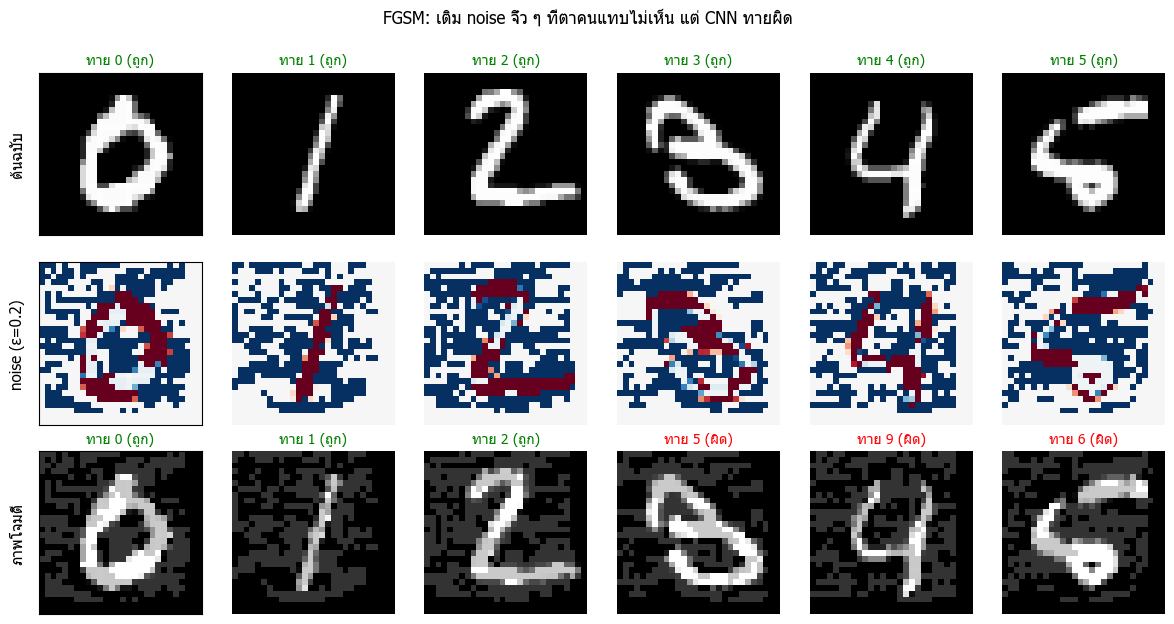

In [14]:
# ── ดูภาพ: ต้นฉบับ -> noise -> ภาพโจมตี (ตาคนยังอ่านออก แต่โมเดลพลาด) ──
idx = [np.where(y_test == d)[0][0] for d in [0, 1, 2, 3, 4, 5]]   # เลือกเลข 0-5 อย่างละรูป
orig = x_test[idx]; true = y_test[idx]
eps = 0.20
adv = fgsm(cnn, orig, true, eps)
perturb = adv - orig

pred_orig = cnn.predict(orig[..., None], verbose=0).argmax(1)
pred_adv  = cnn.predict(adv[..., None],  verbose=0).argmax(1)

fig, axes = plt.subplots(3, 6, figsize=(12, 6.2))
for j in range(6):
    axes[0, j].imshow(orig[j], cmap="gray")
    axes[0, j].set_title(f"ทาย {pred_orig[j]} (ถูก)", color="green", fontsize=10)
    axes[1, j].imshow(perturb[j], cmap="RdBu")                      # noise ที่เติม (ขยายให้เห็น)
    axes[2, j].imshow(adv[j], cmap="gray")
    ok = pred_adv[j] == true[j]
    axes[2, j].set_title(f"ทาย {pred_adv[j]} ({'ถูก' if ok else 'ผิด'})",
                         color="green" if ok else "red", fontsize=10)
    for r in range(3): axes[r, j].axis("off")
for r, lab in enumerate(["ต้นฉบับ", f"noise (ε={eps})", "ภาพโจมตี"]):
    axes[r, 0].set_ylabel(lab, rotation=90, fontsize=11, labelpad=10)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle("FGSM: เติม noise จิ๋ว ๆ ที่ตาคนแทบไม่เห็น แต่ CNN ทายผิด", y=1.0)
plt.tight_layout(); plt.show()

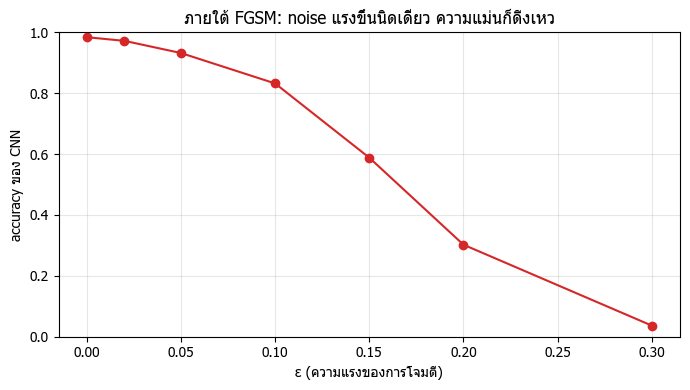

accuracy: ภาพปกติ 98%  ->  ε=0.1 เหลือ 83%  ->  ε=0.3 เหลือ 4%

เชื่อมกับสาย network: หลักการเดียวกันคือ attacker ปรับแต่ง flow/payload เพียงเล็กน้อย
ให้ยังโจมตีสำเร็จ แต่ 'เนียน' พอจะหลอกโมเดลตรวจจับ = adversarial evasion


In [15]:
# ── ยิ่ง ε แรง โมเดลยิ่งพัง: วัด accuracy ภายใต้การโจมตี ──
subset = np.random.default_rng(0).choice(len(x_test), 500, replace=False)
xs, ys = x_test[subset], y_test[subset]

eps_list = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
accs = []
for e in eps_list:
    xa = fgsm(cnn, xs, ys, e) if e > 0 else xs
    accs.append((cnn.predict(xa[..., None], verbose=0).argmax(1) == ys).mean())

plt.figure(figsize=(7, 4))
plt.plot(eps_list, accs, "o-", color="tab:red")
plt.xlabel("ε (ความแรงของการโจมตี)"); plt.ylabel("accuracy ของ CNN")
plt.title("ภายใต้ FGSM: noise แรงขึ้นนิดเดียว ความแม่นก็ดิ่งเหว")
plt.grid(alpha=0.3); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

print(f"accuracy: ภาพปกติ {accs[0]:.0%}  ->  ε=0.1 เหลือ {accs[3]:.0%}  ->  ε=0.3 เหลือ {accs[-1]:.0%}")
print("\nเชื่อมกับสาย network: หลักการเดียวกันคือ attacker ปรับแต่ง flow/payload เพียงเล็กน้อย")
print("ให้ยังโจมตีสำเร็จ แต่ 'เนียน' พอจะหลอกโมเดลตรวจจับ = adversarial evasion")

---
## Part 6 — จากแล็บสู่ของจริง

ทั้งเล่มนี้ใช้**ข้อมูลสังเคราะห์**ที่สะอาดและแยกง่ายกว่าความจริงมาก เพื่อให้เห็นหลักการชัด ๆ
ของจริงโหดกว่านี้หลายเท่า — นี่คือสิ่งที่ต้องรู้เมื่อก้าวออกจากแล็บ

### 📦 Dataset จริงที่ควรไปลองต่อ
- **NSL-KDD / KDD'99** — dataset คลาสสิกสำหรับ intrusion detection (เริ่มง่าย แต่เก่าและไม่สะท้อนยุคนี้แล้ว)
- **CICIDS2017 / CSE-CIC-IDS2018** — traffic + การโจมตีสมัยใหม่ (DDoS, brute force, web attack) พร้อม flow features จาก CICFlowMeter
- **CTU-13** — traffic ของ botnet จริงสำหรับงาน DGA / C2 detection
- **UNSW-NB15** — อีกชุดมาตรฐานสำหรับ network IDS

### ⚙️ ระบบจริงทำงานยังไง
- **Zeek** (เดิมชื่อ Bro) — เครื่องมือสกัด network flow/log ระดับ production แล้วป้อนต่อให้ ML
- **Encrypted Traffic Analysis** — ยุค TLS ทุกที่ ดู payload ไม่ได้ ต้องวิเคราะห์จาก metadata (ขนาด/จังหวะ packet, JA3 fingerprint) — ตรงกับ Part 2 ที่โมเดลเรียนจากรูปร่าง flow
- **SIEM + UEBA** — รวม log จากทั้งองค์กรแล้วใช้ ML จับพฤติกรรมผิดปกติของ user/host

### ⚠️ ความท้าทายที่แล็บไม่ได้สอน
- **False positive ที่ line rate** — 1% ของล้าน flow = alert หมื่นครั้ง → ต้องลด FP สุดชีวิต (เรื่องใหญ่สุดของงานจริง)
- **Concept drift** — traffic ปกติเปลี่ยนตลอด (app ใหม่, พฤติกรรมใหม่) โมเดลเก่าจะแม่นลงเรื่อย ๆ ต้อง retrain
- **Class imbalance** — การโจมตีจริงเป็นเศษเสี้ยวเล็กมากของ traffic → accuracy หลอกตา (ดู `ML_Fundamentals` Part 6)
- **Adversarial robustness** — attacker ปรับตัวหนีโมเดลตลอด (Part 5) เป็นเกมแมวจับหนูที่ไม่จบ
- **ขาด label** — ข้อมูล traffic จริงแทบไม่มีคนมานั่ง label → unsupervised (Part 3) จึงสำคัญมาก

---

### 🎓 สรุปทั้ง 3 เล่ม

| เล่ม | แก่น | จุดเด่น |
|---|---|---|
| **1 — ML Fundamentals** | neuron → backprop → CNN → attention → mini GPT | เข้าใจกลไกจากการเขียนเอง |
| **2 — LLM Deep Dive** | tokenizer → pretrain → sampling → fine-tune | แกะ LLM ทีละชิ้น |
| **3 — ML × Network Security** | classical ML → unsupervised → adversarial | **เอา ML ไปใช้แก้ปัญหาจริง** |

> สามเล่มนี้ครอบคลุมแกนหลักของ ML สมัยใหม่: supervised (เล่ม 1, 3), unsupervised (เล่ม 3),
> deep learning & sequence models (เล่ม 1, 2), และมุมมอง security/robustness (เล่ม 3)
> ทุกอย่างยังตั้งอยู่บนวงจรเดียวจากเล่มแรก — **forward → loss → backprop → update**

### แหล่งเรียนรู้ต่อสาย ML Security
- 📚 *Machine Learning and Security* (Chio & Freeman, O'Reilly) — ตำราตั้งต้นของสายนี้
- 🛠️ **scikit-learn** user guide — ครบทุกอัลกอริทึม classical ML ที่ใช้ใน Part 2–3
- 🎯 **Adversarial Robustness Toolbox (ART)** ของ IBM — ไลบรารีสำหรับโจมตี/ป้องกันโมเดล (ต่อยอด Part 5)
- 🌐 **Zeek** documentation — ลองสกัด flow จาก pcap จริงด้วยตัวเอง